# Results and Interpretation

Consolidated report for the CMP4336 bike-sharing demand project. It pulls together the model comparison, the best model's out-of-sample error analysis, and the feature-importance story, and reads them against the proposal's three questions: **environmental impact**, **temporal patterns**, and the **sequential-data** objective. All numbers come from `reports/metrics.json` and the processed data; the prose summary lives in `reports/RESULTS.md`. Metrics are reported as a set (RMSLE, RMSE, MAE, R²) and interpreted together.

## Setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bike_sharing.config import load_config, load_models_config
from bike_sharing.data import load_raw_train
from bike_sharing.features import build_features
from bike_sharing.models import get_model
from bike_sharing.preprocessing import drop_leakage_columns
from bike_sharing.evaluate import report
from bike_sharing.train import day_of_month_holdout_split

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
MODEL_PARAMS = load_models_config(PROJECT_ROOT / "config" / "models.yaml")
REPORTS_DIR = Path(CFG["paths"]["reports_dir"])
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
metrics = json.loads((REPORTS_DIR / "metrics.json").read_text())

sns.set_theme(context="notebook", style="whitegrid")
print("models evaluated:", sorted(metrics))


models evaluated: ['gradient_boosting', 'hourly_mean_baseline', 'mean_baseline', 'random_forest', 'ridge', 'xgboost']


## 1. Model comparison

Two leakage-safe validation views per model: chronological `TimeSeriesSplit(5)` (forecast future months) and the day-of-month holdout (train days 1-15, validate days 16-19), which mirrors the dataset's own train/test structure. Sorted by holdout RMSLE; lower is better for RMSLE/RMSE/MAE, higher for R².

In [2]:
# Full comparison: every model, both leakage-safe validation views, all
# four metrics read together (no single deciding score).
rows = []
for name, summary in metrics.items():
    cv = summary["cv"]["mean"]
    ho = summary["day_of_month_holdout"]["metrics"]
    rows.append({
        "model": name,
        "holdout_rmsle": ho["rmsle"], "holdout_rmse": ho["rmse"],
        "holdout_mae": ho["mae"], "holdout_r2": ho["r2"],
        "cv_rmsle": cv["rmsle"], "cv_rmse": cv["rmse"],
        "cv_mae": cv["mae"], "cv_r2": cv["r2"],
    })
leaderboard = pd.DataFrame(rows).set_index("model").sort_values("holdout_rmsle")
leaderboard.round(3)


,holdout_rmsle,holdout_rmse,holdout_mae,holdout_r2,cv_rmsle,cv_rmse,cv_mae,cv_r2
model,,,,,,,,
xgboost,0.306,47.540,28.000,0.933,0.463,80.774,54.643,0.766
gradient_boosting,0.312,51.660,31.047,0.920,0.453,84.579,57.138,0.746
random_forest,0.328,51.805,29.909,0.920,0.515,94.900,66.232,0.674
ridge,0.718,140.811,89.064,0.408,0.806,157.815,104.199,0.219
hourly_mean_baseline,0.755,125.884,86.065,0.527,0.739,142.972,99.341,0.348
mean_baseline,1.531,183.077,142.644,-0.001,1.402,196.381,149.341,-0.206


## 2. Best model — out-of-sample error analysis

The strongest model is refit on the early days of each month and scored on the later days it never saw, so the residuals below are honest generalization errors, not in-sample artifacts.

In [3]:
# Pick the best model by day-of-month holdout RMSLE (the more realistic
# view), then rebuild its out-of-sample predictions: fit on days 1-15,
# predict on the held-out days 16-19 it never saw. These residuals are a
# genuine generalization view for the error analysis below.
best_name = leaderboard.index[0]
print("best model by holdout RMSLE:", best_name)

train = drop_leakage_columns(build_features(load_raw_train(CFG), CFG), CFG)
y = train["count"].to_numpy(float)
dt = train[CFG["datetime_col"]]
X = train.drop(columns=["count", CFG["datetime_col"]])

tr_idx, ho_idx = day_of_month_holdout_split(dt)
# Use the same config/models.yaml hyperparameters as the metrics table,
# so this refit reproduces the leaderboard's holdout score rather than
# training the factory defaults.
best = get_model(best_name, CFG, MODEL_PARAMS.get(best_name, {})).fit(
    X.iloc[tr_idx], y[tr_idx]
)
y_true = y[ho_idx]
y_pred = best.predict(X.iloc[ho_idx])

err = X.iloc[ho_idx].copy()
err["actual"] = y_true
err["pred"] = y_pred
err["residual"] = y_pred - y_true
print("holdout report:", {k: round(v, 3) for k, v in report(y_true, y_pred).items()})


best model by holdout RMSLE: xgboost


holdout report: {'rmsle': 0.306, 'rmse': 47.54, 'mae': 28.0, 'r2': 0.933}


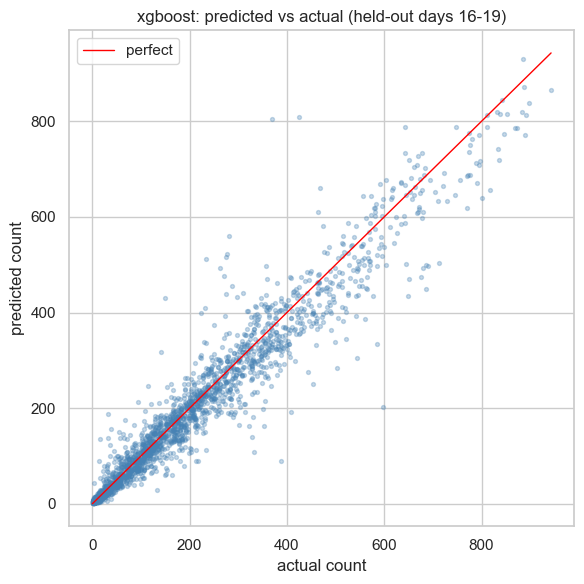

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(err["actual"], err["pred"], s=8, alpha=0.3, color="steelblue")
lim = max(err["actual"].max(), err["pred"].max())
ax.plot([0, lim], [0, lim], color="red", linewidth=1, label="perfect")
ax.set_title(f"{best_name}: predicted vs actual (held-out days 16-19)")
ax.set_xlabel("actual count")
ax.set_ylabel("predicted count")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "14_best_model_pred_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()


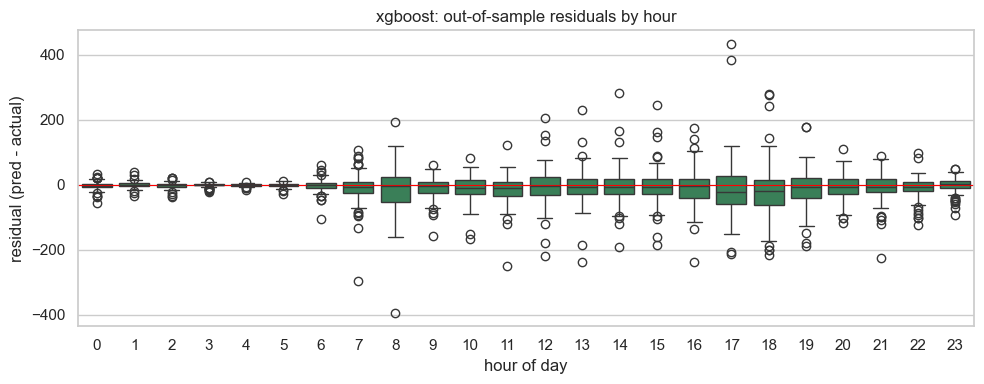

In [5]:
# Residuals by hour. Contrast with Ridge's residuals in notebook 03:
# the tree model's errors should hug zero across the whole day, showing
# it captured the bimodal commuter pattern the linear model missed.
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=err, x="hour", y="residual", color="seagreen", ax=ax)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_title(f"{best_name}: out-of-sample residuals by hour")
ax.set_xlabel("hour of day")
ax.set_ylabel("residual (pred - actual)")
fig.tight_layout()
fig.savefig(FIG_DIR / "15_best_model_residuals_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Environmental error analysis

Where does the model err under different weather and seasonal conditions? This is the environmental-impact lens on the errors.

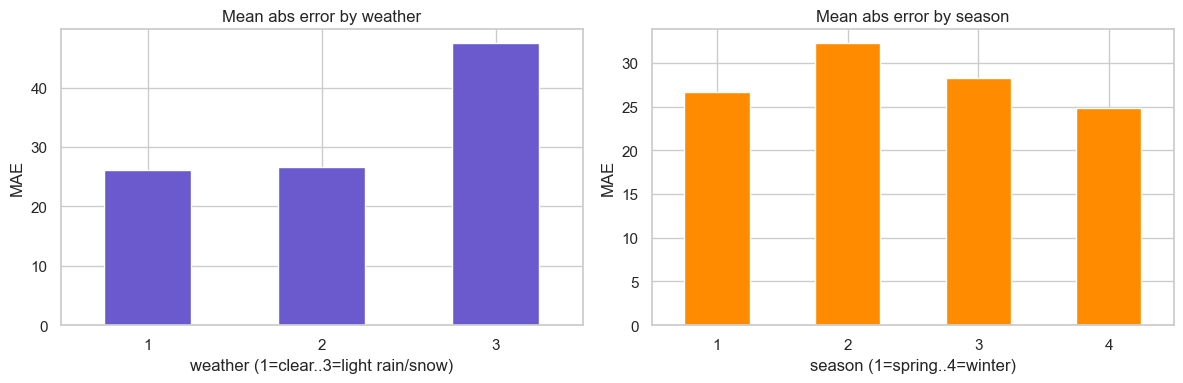

,mean,count
weather,,
1,26.16,1440
2,26.65,663
3,47.42,183


In [6]:
# Environmental error analysis: mean absolute error by weather category
# and by season. Shows whether the model degrades in adverse conditions
# (the environmental-impact question from the proposal).
err["abs_error"] = err["residual"].abs()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_weather = err.groupby("weather")["abs_error"].mean()
by_weather.plot(kind="bar", color="slateblue", ax=axes[0])
axes[0].set_title("Mean abs error by weather")
axes[0].set_xlabel("weather (1=clear..3=light rain/snow)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=0)

by_season = err.groupby("season")["abs_error"].mean()
by_season.plot(kind="bar", color="darkorange", ax=axes[1])
axes[1].set_title("Mean abs error by season")
axes[1].set_xlabel("season (1=spring..4=winter)")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "16_error_by_environment.png", dpi=120, bbox_inches="tight")
plt.show()
err.groupby("weather")["abs_error"].agg(["mean", "count"]).round(2)


## 4. Error by demand level and commute structure

Two further views of the same held-out residuals. The demand-quintile breakdown shows error grows with demand level - RMSE and MAE are smallest in the low-demand bins and largest in the top quintile - and the mean bias turns negative in the top bin, i.e. the model slightly under-predicts the busiest hours (the log1p target plus the high variance of peak demand). The hour x workingday error heatmap localizes the residuals to the working-day commute peaks, which is exactly where demand is highest; the model handles the flat overnight hours almost perfectly.

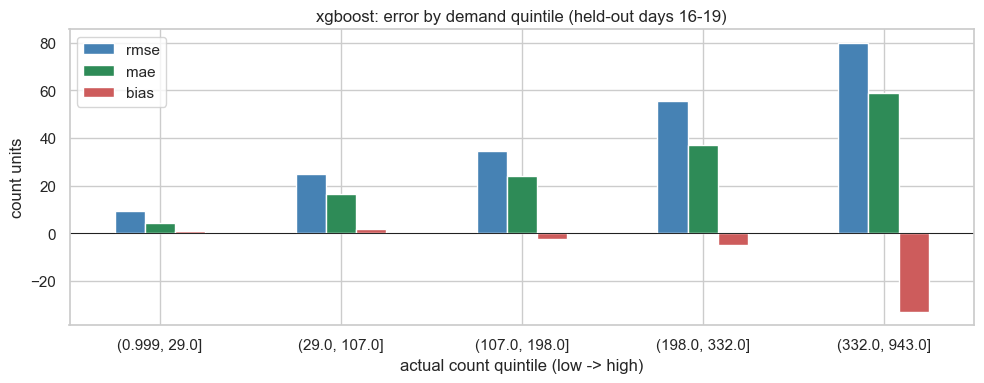

,rmse,mae,bias,n
demand_bin,,,,
"(0.999, 29.0]",9.49,4.50,0.97,460
"(29.0, 107.0]",24.84,16.52,1.94,459
"(107.0, 198.0]",34.60,23.99,-2.29,459
"(198.0, 332.0]",55.58,36.87,-4.78,456
"(332.0, 943.0]",79.87,58.69,-32.93,452


In [7]:
# Where does error concentrate by demand level? Bin the held-out actuals
# into quintiles and report RMSE, MAE, and mean bias (pred - actual) per
# bin. Squared-error metrics are dominated by the high-demand tail, so
# this exposes whether the model systematically under-predicts peak hours.
err["demand_bin"] = pd.qcut(err["actual"], 5, duplicates="drop")
by_bin = err.groupby("demand_bin", observed=True).agg(
    rmse=("residual", lambda r: float(np.sqrt(np.mean(r ** 2)))),
    mae=("abs_error", "mean"),
    bias=("residual", "mean"),
    n=("residual", "size"),
)

fig, ax = plt.subplots(figsize=(10, 4))
by_bin[["rmse", "mae", "bias"]].plot(
    kind="bar", ax=ax, color=["steelblue", "seagreen", "indianred"]
)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title(f"{best_name}: error by demand quintile (held-out days 16-19)")
ax.set_xlabel("actual count quintile (low -> high)")
ax.set_ylabel("count units")
ax.tick_params(axis="x", rotation=0)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "21_error_by_demand_quantile.png", dpi=120, bbox_inches="tight")
plt.show()
by_bin.round(2)


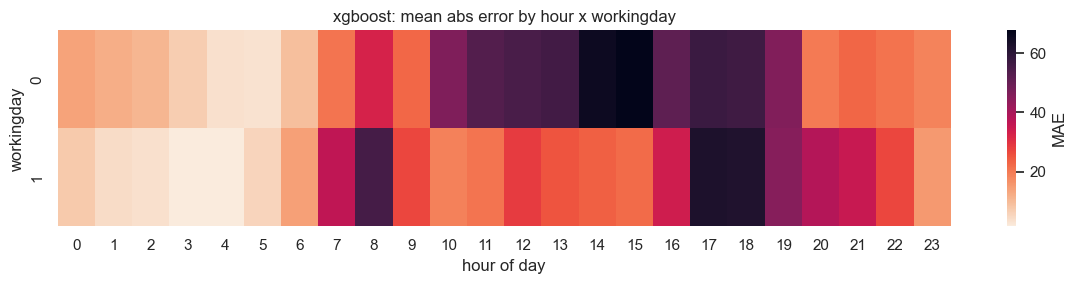

In [8]:
# Commute-hour error structure: mean absolute error across hour x
# workingday. The largest absolute errors should sit in the working-day
# rush hours, where demand is highest and most variable - the same
# interaction the linear baseline could not represent.
pivot = err.pivot_table(
    index="workingday", columns="hour", values="abs_error", aggfunc="mean",
)
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(pivot, cmap="rocket_r", ax=ax, cbar_kws={"label": "MAE"})
ax.set_title(f"{best_name}: mean abs error by hour x workingday")
ax.set_xlabel("hour of day")
ax.set_ylabel("workingday")
fig.tight_layout()
fig.savefig(FIG_DIR / "22_error_by_workingday_hour.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Permutation importance (model-agnostic)

Notebook 04's importances are impurity-based: a fast diagnostic, but biased toward continuous/high-cardinality columns and free to split importance arbitrarily between correlated inputs like `temp`/`atemp`. Permutation importance instead measures the real increase in held-out error when each feature is shuffled. It is computed here on the held-out days 16-19 with the model fit only on days 1-15, and scored with the same count-scale RMSLE used everywhere else - an honest, model-agnostic view of what the deployed model actually relies on.

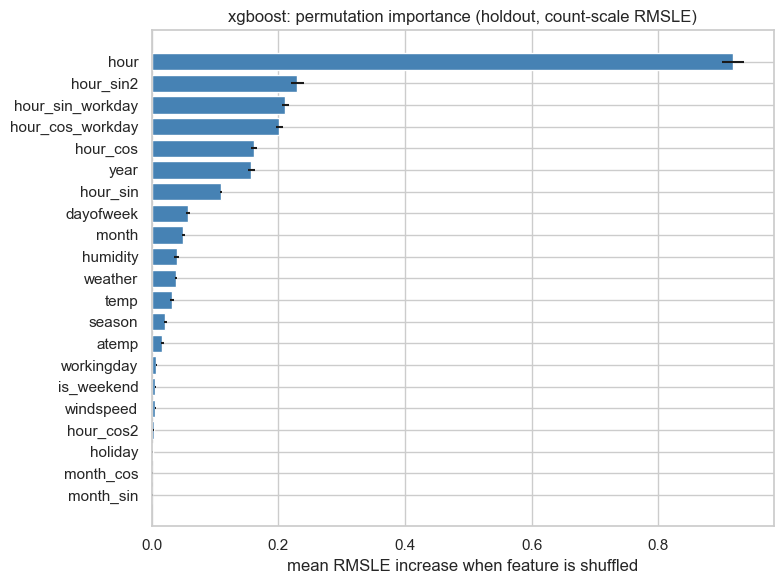

,feature,importance_mean,importance_std
0,hour,0.9184,0.0173
1,hour_sin2,0.2302,0.0102
2,hour_sin_workday,0.2113,0.0058
3,hour_cos_workday,0.2017,0.0050
4,hour_cos,0.1620,0.0043
5,year,0.1577,0.0055
6,hour_sin,0.1092,0.0018
7,dayofweek,0.0572,0.0034
8,month,0.0503,0.0023
9,humidity,0.0396,0.0035


In [9]:
# Model-agnostic permutation importance for the best model, computed on the
# day-of-month holdout (days 16-19) using the model fit on days 1-15 only
# (`best`, refit above) - never the full-train models/*.joblib, which has
# already seen these rows. Importance is scored with count-scale RMSLE (the
# metric the models are judged on), so it is directly comparable to the
# leaderboard and free of the impurity bias in notebook 04's figure 13.
from bike_sharing.explain import rmsle_permutation_importance

perm = rmsle_permutation_importance(
    best, X.iloc[ho_idx], y[ho_idx], seed=CFG["seed"], n_repeats=10
)

fig, ax = plt.subplots(figsize=(8, 6))
order = perm.sort_values("importance_mean")  # ascending so the top bar is largest
ax.barh(
    order["feature"], order["importance_mean"],
    xerr=order["importance_std"], color="steelblue",
)
ax.set_title(f"{best_name}: permutation importance (holdout, count-scale RMSLE)")
ax.set_xlabel("mean RMSLE increase when feature is shuffled")
fig.tight_layout()
fig.savefig(FIG_DIR / "23_permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()
perm.round(4)


## 6. Interpretation

**Temporal patterns (primary signal).** Demand is driven first by time-of-day, and the shape differs sharply between working and non-working days (the bimodal commuter peak vs a single afternoon peak). Ridge with only first-harmonic cyclic features could not represent two peaks per day and lost to the trivial hour-of-day average; the feature experiment (`docs/experiments/2026-06-01_leakage-safe-feature-sweep.md`) added a second hour harmonic and workingday-gated cyclic terms and lifted Ridge just past that baseline (0.91 -> 0.72), an explainability gain that confirms the bimodal shape was the binding constraint. The tree/boosting models capture the `hour × workingday` interaction non-linearly and roughly halve the error again. Holdout permutation importance (section 5, figure 23) puts `hour` far ahead, followed by the engineered cyclic terms (`hour_sin2` and the workingday-gated `hour_sin_workday`/`hour_cos_workday`), then `hour_cos`, `hour_sin`, and `year`; the raw `workingday` flag itself ranks low because the workingday-gated cyclic features already carry that signal.

**Environmental impact (secondary signal).** Temperature, humidity, weather category, and season form a real but secondary tier: they modulate demand around the dominant daily rhythm rather than setting it, and the per-condition error analysis above shows where the model is least certain. This matches the EDA: demand rises with temperature and falls with humidity and worse weather.

**Sequential-data objective.** The proposal raised a sequential-analysis goal (target lags such as `count(t-1)`). We deliberately did **not** add target-lag features: the test set covers later days with no observed counts, so a lag feature cannot be built at inference time without true future targets, and would leak during validation. The temporal signal is instead captured through calendar and cyclic features. A leakage-safe sequential experiment would require recursive multi-step generation at inference and a matching recursive validation protocol; it is scoped as optional future work, documented before any code per the experiment-log rules.

**Model choice.** XGBoost leads the day-of-month holdout (the primary view), while Gradient Boosting is marginally ahead on the chronological CV (0.453 vs 0.463) and Random Forest sits just behind; the three should be read as a near-tie rather than a decisive winner from one metric. The hour-of-day mean is a remarkably strong, interpretable baseline: the engineered Ridge only just edges it, and only the non-linear models beat it by a wide margin.

**Limitations.** Hyperparameters are sensible defaults, not tuned; impurity-based importances (figure 13) are a quick diagnostic, complemented here by holdout permutation importance (section 5, figure 23); and `day`-of-month was excluded because train and test do not overlap on it. See `reports/RESULTS.md` for the written summary.